# Réconciliation éCO2mix — de bout en bout

**Bloc 5 · W37.** Ce notebook est la *Definition of Done* du mini-projet : il tourne **de bout en bout, sans
intervention** (`Run All`), depuis le téléchargement jusqu'au chiffre clé. Les explications détaillées sont
dans les quatre notebooks de `notebooks/` ; celui-ci exécute et vérifie.

| Étape | Ce qui est vérifié |
|---|---|
| 1. Données | téléchargées si absentes, sha256 contrôlés, défaut d'heure corrigé, additivité testée |
| 2. Backtest | 4 origines espacées de 7 jours, h = 24, fenêtre strictement antérieure |
| 3. Assertion | `incohérence < 1e-6` pour toute méthode réconciliée, sinon **échec** |
| 4. Tableau | MASE × (niveau, méthode), moyenne et écart-type entre origines |
| 5. Figure | MASE par niveau et par méthode (`figures/figure_cle.png` et `.svg`) |
| 6. Chiffre clé | de combien MinT bouge le MASE **régional** par rapport au bottom-up |

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown
from w37_reconciliation import viz
from w37_reconciliation.eco2mix import run, metrics, figures, inference

viz.setup()
cfg, paths = run.load_config()
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

## 1. Données

In [2]:
if not (paths.raw / "manifest.json").exists():
    run.download(cfg, paths)                       # environ 5 minutes, une seule fois
run.run_prepare(cfg, paths)                         # contrôle des sha256, nettoyage, additivité
hier = run.load_hierarchy(cfg, paths)               # lève une erreur si une série est incomplète

  12 régions × 105,191 heures (2013-01-01 → 2024-12-31 22:00 UTC)
  heures imputées : 144 ; doublons retirés : 288
  additivité national − Σ régions : médiane +0.00 MW ; max |écart| par année ≤ 6 MW sauf {2013: 14.0, 2016: 215.0}


## 2. Backtest du protocole principal

In [3]:
res = run.run_backtest_stage(cfg, paths, "main")
fc, scales = res["forecasts"], res["scales"]

  main : 4 origines, 13 séries


  [1/4] 2024-11-05 Tue λ=0.024


  [2/4] 2024-11-12 Tue λ=0.023


  [3/4] 2024-11-19 Tue λ=0.022


  [4/4] 2024-11-26 Tue λ=0.023


## 3. Assertion de cohérence

In [4]:
RECONCILED = ["BU", "OLS", "WLS struct", "WLS var", "MinT shrink"]
tol = float(cfg["inference"]["coherence_tol_abs"])
incoh = metrics.assert_coherent(fc, hier, RECONCILED, tol)
assert incoh.to_numpy().max() < tol
print(f"OK : incohérence max {incoh.to_numpy().max():.1e} MW < {tol:g} pour {len(RECONCILED)} méthodes × "
      f"{fc['origin'].nunique()} origines")

OK : incohérence max 0.0e+00 MW < 1e-06 pour 5 méthodes × 4 origines


## 4. Tableau MASE × (niveau, méthode)

In [5]:
by_level = metrics.mase_by_level(metrics.mase_long(fc, scales, hier))
table = metrics.summary_table(by_level, ["SN", "base", *RECONCILED])
table.to_csv(FIG / "tableau_mase_principal.csv")
display(table.style.format("{:.3f}").highlight_min(subset=["France mean", "Régions mean"], color="#cde2fb"))

,France mean,France std,Régions mean,Régions std
method,,,,
SN,0.817,0.329,0.825,0.152
base,0.467,0.520,0.580,0.464
BU,0.500,0.607,0.580,0.464
OLS,0.469,0.527,0.544,0.388
WLS struct,0.481,0.564,0.560,0.423
WLS var,0.485,0.573,0.567,0.438
MinT shrink,0.463,0.507,0.542,0.383


## 5. Figure

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


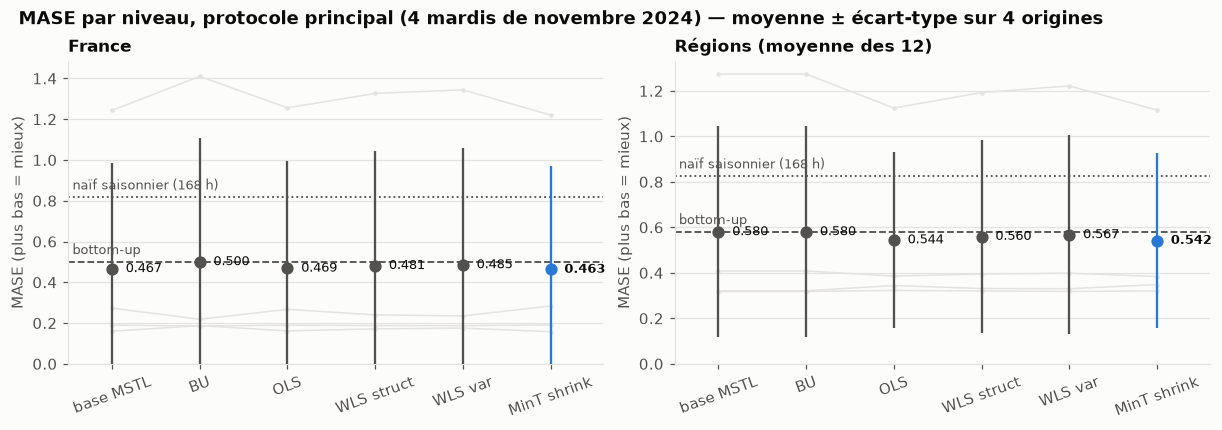

In [6]:
fig = figures.key_figure(by_level, "MASE par niveau, protocole principal (4 mardis de novembre 2024)")
fig.savefig(FIG / "figure_cle.png", dpi=150, bbox_inches="tight")
fig.savefig(FIG / "figure_cle.svg", bbox_inches="tight")

## 6. Le chiffre clé

In [7]:
k = metrics.key_figure(by_level, "MinT shrink", "BU")
r = k["Régions"]
w = by_level[by_level["level"] == "Régions"].pivot(index="origin", columns="method", values="mase")
pc = inference.paired_comparison(w["MinT shrink"], w["BU"])
display(Markdown(
    f"**Protocole principal (4 origines)** : MinT shrink fait varier le MASE régional de **{r['mean']:+.1%}** "
    f"par rapport au bottom-up (écart-type {r['std']:.1%} ; meilleur à {r['wins']}/{r['n_origins']} origines ; "
    f"p = {pc['t_p']:.2f}, non significatif)."))

rob = paths.results / "robustness_forecasts.parquet"
if rob.exists():
    rr = run.load_results(paths, "robustness")
    bl = metrics.mase_by_level(metrics.mase_long(rr["forecasts"], rr["scales"], hier))
    kr = metrics.key_figure(bl, "MinT shrink", "BU")["Régions"]
    display(Markdown(
        f"**Étude de robustesse ({kr['n_origins']} origines de 2024)** : **{kr['mean']:+.1%}** "
        f"(meilleur à {kr['wins']}/{kr['n_origins']} origines). Le bottom-up reste la meilleure "
        f"réconciliation ; voir `notebooks/04_robustesse_et_tests.ipynb`."))
else:
    display(Markdown("Étude de robustesse non calculée : `uv run w37 eco2mix backtest --which robustness`."))

**Protocole principal (4 origines)** : MinT shrink fait varier le MASE régional de **-2.2%** par rapport au bottom-up (écart-type 9.0% ; meilleur à 2/4 origines ; p = 0.43, non significatif).

**Étude de robustesse (119 origines de 2024)** : **+2.2%** (meilleur à 48/119 origines). Le bottom-up reste la meilleure réconciliation ; voir `notebooks/04_robustesse_et_tests.ipynb`.